# Churn Customer Analysis
## วิเคราะห์พฤติกรรมลูกค้าที่หยุดซื้อ (Churn) ด้วย Clustering

**วัตถุประสงค์:** วิเคราะห์ลูกค้า 296,351 คนที่ซื้อในงวด 2026-02-16 แต่ไม่ซื้อในงวด 2026-03-01  
**เป้าหมาย:** แบ่งกลุ่มลูกค้าที่ churn ด้วย K-Means Clustering เพื่อเข้าใจพฤติกรรมและสัญญาณเตือน  
**ข้อมูล:** `Churn_0301_VSCODE.csv`

---
## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# ตั้งค่า matplotlib ให้แสดงภาษาไทย
plt.rcParams['font.family'] = 'Tahoma'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# โหลดข้อมูล
df = pd.read_csv('Churn_0301_VSCODE.csv', na_values=['null'])
print(f'Shape: {df.shape}')
print(f'จำนวนลูกค้า: {len(df):,} คน')
print(f'จำนวนคอลัมน์: {df.shape[1]}')
print()
df.head(3)

Shape: (296351, 74)
จำนวนลูกค้า: 296,351 คน
จำนวนคอลัมน์: 74



,userNo,age,gender,province,RegisteredRoundDate,FirstPurchaseRoundDate,LastPurchaseRoundDate,item2026_02_16,item2026_03_01,item2023_07_01,...,item2025_10_16,item2025_11_01,item2025_11_16,item2025_12_01,item2025_12_16,item2026_01_02,item2026_01_17,item2026_02_01,item2026_02_16.1,item2026_03_01.1
0,P13414787,34,MALE,สมุทรปราการ,2026-02-16,2026-02-16,2026-02-16,4,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,0
1,P6127413,41,MALE,ชลบุรี,2023-07-01,2023-08-16,2026-02-16,1,0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0
2,P10387269,36,MALE,นครศรีธรรมราช,2024-12-01,2024-12-01,2026-02-16,3,0,NaN,...,0.0,0.0,3.0,3.0,0.0,0.0,4.0,0.0,3,0


In [3]:
# ตรวจสอบ dtypes และ missing values
print('=== Data Types ===')
print(df.dtypes.value_counts())
print()
print('=== Missing Values (Top 10) ===')
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False).head(10))
print()
print('=== ข้อมูลเบื้องต้น ===')
print(f"อายุ: {df['age'].min()} - {df['age'].max()} ปี (เฉลี่ย {df['age'].mean():.1f})")
print(f"เพศ: {df['gender'].value_counts().to_dict()}")
print(f"จังหวัด: {df['province'].nunique()} จังหวัด")

=== Data Types ===
float64    63
object      6
int64       5
Name: count, dtype: int64

=== Missing Values (Top 10) ===
item2023_07_01    278087
item2023_07_16    262857
item2023_07_30    247014
item2023_08_16    237270
item2023_09_01    230746
item2023_09_16    221410
item2023_10_01    214804
item2023_10_16    209426
item2023_11_01    205031
item2023_11_16    200678
dtype: int64

=== ข้อมูลเบื้องต้น ===
อายุ: 0 - 2025 ปี (เฉลี่ย 76.3)
เพศ: {'FEMALE': 139711, 'MALE': 126864, 'UNSPECIFIED': 29776}
จังหวัด: 78 จังหวัด


In [4]:
# แยกคอลัมน์ item (รายงวด) — เรียงตามลำดับเวลา
item_cols_all = [c for c in df.columns if c.startswith('item')]

# ตรวจสอบคอลัมน์ซ้ำ (pandas จะต่อ .1 ให้อัตโนมัติ)
# item2026_02_16 และ item2026_03_01 ปรากฏ 2 ครั้ง → ตัวท้ายจะเป็น .1
# คอลัมน์แรก (ตำแหน่ง 7-8) เป็นข้อมูลเดียวกับคอลัมน์ท้าย → ใช้ตัวเดียว
dupes = [c for c in item_cols_all if '.1' in c]
if dupes:
    print(f'พบคอลัมน์ซ้ำ (pandas suffix): {dupes}')
    # ตัดคอลัมน์ .1 ออก ใช้ตัวแรกที่ไม่มี .1
    item_cols_all = [c for c in item_cols_all if '.1' not in c]

# แปลงชื่อคอลัมน์เป็นวันที่เพื่อเรียงลำดับ
def col_to_date(col):
    # ตัด suffix .1 ออก (กรณีซ้ำ)
    clean = col.replace('item', '').split('.')[0]
    return pd.to_datetime(clean, format='%Y_%m_%d')

item_cols_sorted = sorted(item_cols_all, key=col_to_date)

# แยกคอลัมน์ — ไม่รวม item2026_03_01 (งวดที่ churn)
item_cols = [c for c in item_cols_sorted if c != 'item2026_03_01']
round_dates = [col_to_date(c) for c in item_cols]

print(f'จำนวนงวดทั้งหมด (ไม่รวมงวด churn): {len(item_cols)}')
print(f'งวดแรก: {round_dates[0].strftime("%Y-%m-%d")} | งวดสุดท้าย: {round_dates[-1].strftime("%Y-%m-%d")}')

พบคอลัมน์ซ้ำ (pandas suffix): ['item2026_02_16.1', 'item2026_03_01.1']
จำนวนงวดทั้งหมด (ไม่รวมงวด churn): 64
งวดแรก: 2023-07-01 | งวดสุดท้าย: 2026-02-16


---
## 2. EDA — Exploratory Data Analysis

### 2.1 Demographics — กระจายตัวของลูกค้าที่ churn

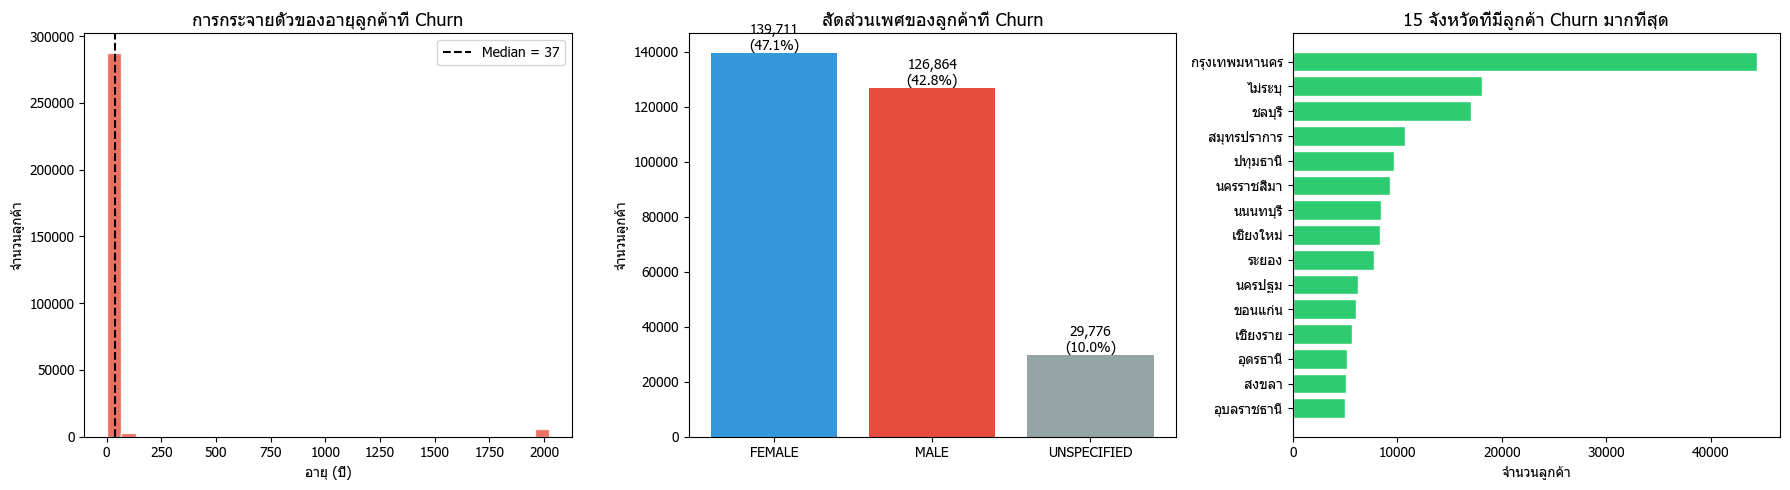

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution
axes[0].hist(df['age'], bins=30, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title('การกระจายตัวของอายุลูกค้าที่ Churn', fontsize=13)
axes[0].set_xlabel('อายุ (ปี)')
axes[0].set_ylabel('จำนวนลูกค้า')
axes[0].axvline(df['age'].median(), color='black', linestyle='--', label=f"Median = {df['age'].median():.0f}")
axes[0].legend()

# Gender distribution
gender_counts = df['gender'].value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=['#3498db', '#e74c3c', '#95a5a6'][:len(gender_counts)])
axes[1].set_title('สัดส่วนเพศของลูกค้าที่ Churn', fontsize=13)
axes[1].set_ylabel('จำนวนลูกค้า')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 1000, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)

# Top 15 provinces
top_provinces = df['province'].value_counts().head(15)
axes[2].barh(top_provinces.index[::-1], top_provinces.values[::-1], color='#2ecc71', edgecolor='white')
axes[2].set_title('15 จังหวัดที่มีลูกค้า Churn มากที่สุด', fontsize=13)
axes[2].set_xlabel('จำนวนลูกค้า')

plt.tight_layout()
plt.show()

### 2.2 Tenure Analysis — อายุสมาชิก

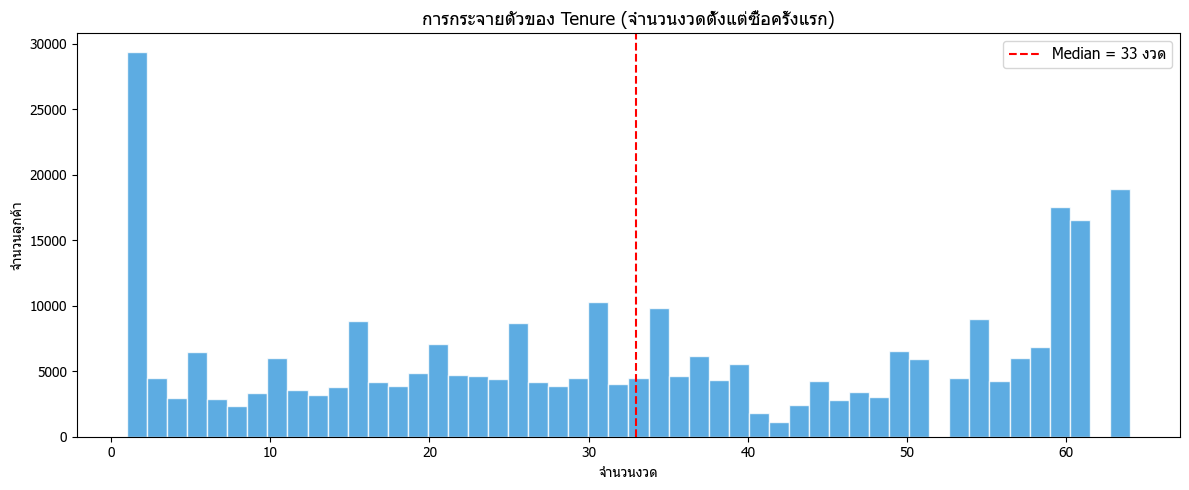

Tenure เฉลี่ย: 33.4 งวด
Tenure มัธยฐาน: 33 งวด
Min: 1 | Max: 64 งวด


In [6]:
# คำนวณ tenure: จำนวนงวดตั้งแต่ซื้อครั้งแรกถึงงวดสุดท้าย (2026-02-16)
last_round_date = pd.to_datetime('2026-02-16')

# หางวดแรกที่ซื้อของแต่ละคน
purchase_data = df[item_cols].fillna(0)

def get_first_purchase_idx(row):
    """หา index ของงวดแรกที่ซื้อ (ค่า > 0)"""
    for i, val in enumerate(row):
        if val > 0:
            return i
    return len(row) - 1  # ถ้าไม่เจอ ให้เป็นงวดสุดท้าย

first_purchase_idx = purchase_data.apply(get_first_purchase_idx, axis=1)
df['tenure_rounds'] = len(item_cols) - first_purchase_idx

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df['tenure_rounds'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
ax.set_title('การกระจายตัวของ Tenure (จำนวนงวดตั้งแต่ซื้อครั้งแรก)', fontsize=13)
ax.set_xlabel('จำนวนงวด')
ax.set_ylabel('จำนวนลูกค้า')
ax.axvline(df['tenure_rounds'].median(), color='red', linestyle='--', label=f"Median = {df['tenure_rounds'].median():.0f} งวด")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Tenure เฉลี่ย: {df['tenure_rounds'].mean():.1f} งวด")
print(f"Tenure มัธยฐาน: {df['tenure_rounds'].median():.0f} งวด")
print(f"Min: {df['tenure_rounds'].min()} | Max: {df['tenure_rounds'].max()} งวด")

### 2.3 Purchase History — ประวัติการซื้อ

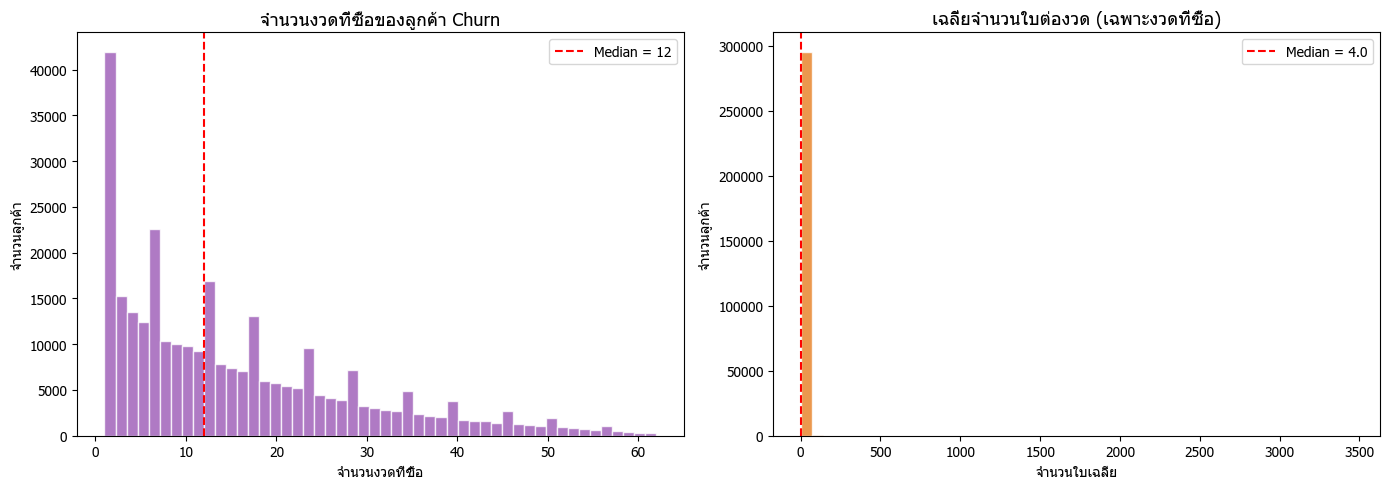

In [7]:
# จำนวนงวดที่ซื้อ
df['total_rounds_purchased'] = (purchase_data > 0).sum(axis=1)

# ค่าเฉลี่ยต่องวดที่ซื้อ
purchase_nonzero = purchase_data.replace(0, np.nan)
df['avg_items_when_buy'] = purchase_nonzero.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['total_rounds_purchased'], bins=50, color='#9b59b6', edgecolor='white', alpha=0.8)
axes[0].set_title('จำนวนงวดที่ซื้อของลูกค้า Churn', fontsize=13)
axes[0].set_xlabel('จำนวนงวดที่ซื้อ')
axes[0].set_ylabel('จำนวนลูกค้า')
axes[0].axvline(df['total_rounds_purchased'].median(), color='red', linestyle='--',
               label=f"Median = {df['total_rounds_purchased'].median():.0f}")
axes[0].legend()

axes[1].hist(df['avg_items_when_buy'].dropna(), bins=50, color='#e67e22', edgecolor='white', alpha=0.8)
axes[1].set_title('เฉลี่ยจำนวนใบต่องวด (เฉพาะงวดที่ซื้อ)', fontsize=13)
axes[1].set_xlabel('จำนวนใบเฉลี่ย')
axes[1].set_ylabel('จำนวนลูกค้า')
axes[1].axvline(df['avg_items_when_buy'].median(), color='red', linestyle='--',
               label=f"Median = {df['avg_items_when_buy'].median():.1f}")
axes[1].legend()

plt.tight_layout()
plt.show()

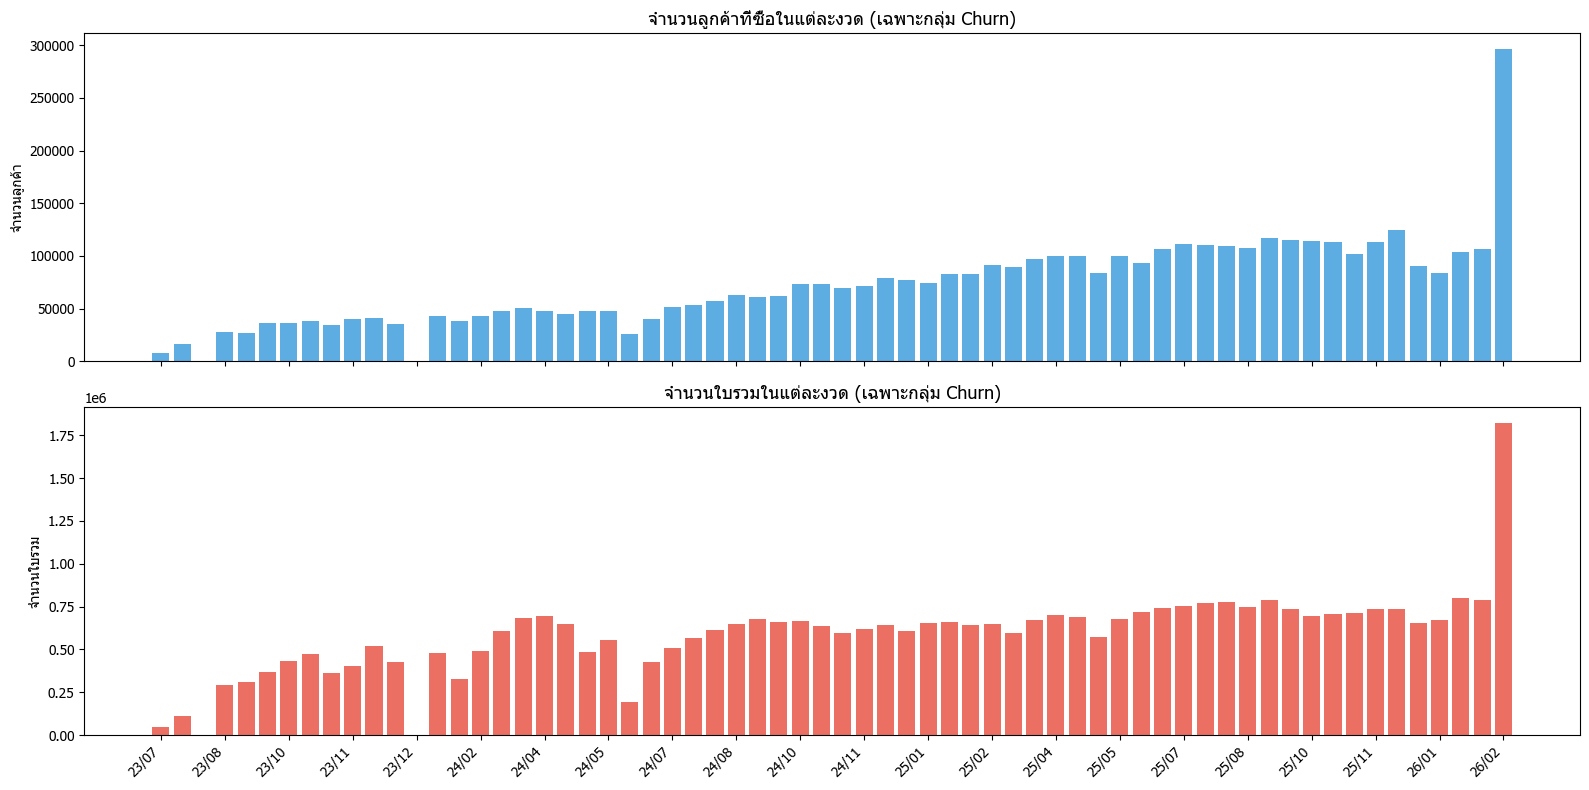

In [8]:
# Trend การซื้อรวมทุกคนในแต่ละงวด
round_totals = purchase_data.sum(axis=0)
round_buyers = (purchase_data > 0).sum(axis=0)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

x_labels = [col_to_date(c).strftime('%y/%m') for c in item_cols]
x_pos = range(len(item_cols))

axes[0].bar(x_pos, round_buyers.values, color='#3498db', alpha=0.8)
axes[0].set_title('จำนวนลูกค้าที่ซื้อในแต่ละงวด (เฉพาะกลุ่ม Churn)', fontsize=13)
axes[0].set_ylabel('จำนวนลูกค้า')

axes[1].bar(x_pos, round_totals.values, color='#e74c3c', alpha=0.8)
axes[1].set_title('จำนวนใบรวมในแต่ละงวด (เฉพาะกลุ่ม Churn)', fontsize=13)
axes[1].set_ylabel('จำนวนใบรวม')
axes[1].set_xticks(x_pos[::3])
axes[1].set_xticklabels([x_labels[i] for i in range(0, len(x_labels), 3)], rotation=45, ha='right')

plt.tight_layout()
plt.show()

---
## 3. Feature Engineering
สร้าง features จากข้อมูลซื้อขายรายงวดเพื่อใช้ใน clustering

In [9]:
# เตรียมข้อมูลงวด — เรียงตามเวลา (เก่า -> ใหม่)
purchase_matrix = df[item_cols].fillna(0).values  # shape: (n_customers, n_rounds)
n_customers, n_rounds = purchase_matrix.shape
print(f'Purchase matrix: {n_customers:,} customers x {n_rounds} rounds')

# --- Feature 1: tenure_rounds (คำนวณแล้วใน EDA) ---
# df['tenure_rounds'] มีอยู่แล้ว

# --- Feature 2: total_rounds_purchased (คำนวณแล้วใน EDA) ---
# df['total_rounds_purchased'] มีอยู่แล้ว

# --- Feature 3: purchase_ratio ---
df['purchase_ratio'] = df['total_rounds_purchased'] / df['tenure_rounds'].clip(lower=1)

# --- Feature 4: avg_items_per_round ---
# เฉลี่ยจำนวนใบต่องวดที่ซื้อ (เฉพาะงวดที่ซื้อ)
df['avg_items_per_round'] = df['avg_items_when_buy'].fillna(0)

# --- Feature 5: max_items_in_round ---
df['max_items_in_round'] = purchase_matrix.max(axis=1)

# --- Feature 6 & 7: recent_3_avg, recent_6_avg ---
# 3 งวดล่าสุด (ก่อน churn) = index -3 ถึง -1
last_3 = purchase_matrix[:, -3:]
last_6 = purchase_matrix[:, -6:]
df['recent_3_avg'] = last_3.mean(axis=1)
df['recent_6_avg'] = last_6.mean(axis=1)

# --- Feature 8: trend (slope ของ 6 งวดล่าสุด) ---
x_trend = np.arange(6)
x_mean = x_trend.mean()
x_var = ((x_trend - x_mean) ** 2).sum()

def calc_slope(y):
    y_mean = y.mean()
    return ((x_trend - x_mean) * (y - y_mean)).sum() / x_var

df['trend'] = np.apply_along_axis(calc_slope, 1, last_6)

print('Features 1-8 done')

Purchase matrix: 296,351 customers x 64 rounds


Features 1-8 done


In [10]:
# --- Feature 9: consecutive_buy_streak (งวดติดต่อกันที่ซื้อก่อน churn) ---
def calc_streak(row):
    streak = 0
    for val in reversed(row):
        if val > 0:
            streak += 1
        else:
            break
    return streak

df['consecutive_buy_streak'] = np.array([calc_streak(purchase_matrix[i]) for i in range(n_customers)])

# --- Feature 10: max_gap (ช่วงว่างยาวที่สุดที่ไม่ซื้อ) ---
def calc_max_gap(row, first_idx):
    """คำนวณ gap ยาวสุดตั้งแต่งวดแรกที่ซื้อ"""
    if first_idx >= len(row):
        return 0
    active = row[first_idx:]
    max_gap = 0
    current_gap = 0
    for val in active:
        if val == 0:
            current_gap += 1
            max_gap = max(max_gap, current_gap)
        else:
            current_gap = 0
    return max_gap

first_idxs = (len(item_cols) - df['tenure_rounds']).values
df['max_gap'] = np.array([calc_max_gap(purchase_matrix[i], first_idxs[i]) for i in range(n_customers)])

# --- Feature 11: items_last_round (จำนวนใบงวดสุดท้าย 2026-02-16) ---
df['items_last_round'] = purchase_matrix[:, -1]  # งวดสุดท้ายใน item_cols = 2026-02-16

# --- Feature 12: age (มีอยู่แล้ว) ---

# --- Feature 13: gender_encoded ---
le = LabelEncoder()
df['gender_encoded'] = le.fit_transform(df['gender'].fillna('UNKNOWN'))
print(f'Gender mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

print('Features 9-13 done')

Gender mapping: {'FEMALE': np.int64(0), 'MALE': np.int64(1), 'UNSPECIFIED': np.int64(2)}
Features 9-13 done


In [11]:
# สรุป features ทั้งหมด
feature_cols = [
    'tenure_rounds', 'total_rounds_purchased', 'purchase_ratio',
    'avg_items_per_round', 'max_items_in_round',
    'recent_3_avg', 'recent_6_avg', 'trend',
    'consecutive_buy_streak', 'max_gap',
    'items_last_round', 'age', 'gender_encoded'
]

print(f'จำนวน features: {len(feature_cols)}')
print()
df[feature_cols].describe().round(2)

จำนวน features: 13



,tenure_rounds,total_rounds_purchased,purchase_ratio,avg_items_per_round,max_items_in_round,recent_3_avg,recent_6_avg,trend,consecutive_buy_streak,max_gap,items_last_round,age,gender_encoded
count,296351.00,296351.00,296351.00,296351.00,296351.00,296351.00,296351.00,296351.00,296351.00,296351.00,296351.00,296351.00,296351.00
mean,33.44,15.64,0.53,6.34,16.34,3.84,3.08,0.57,2.28,8.17,6.15,76.31,0.63
std,20.81,13.44,0.28,14.56,49.37,10.91,8.57,2.50,4.09,8.54,14.87,271.76,0.66
min,1.00,1.00,0.03,1.00,1.00,0.33,0.17,-124.26,1.00,0.00,1.00,0.00,0.00
25%,16.00,5.00,0.30,2.56,5.00,1.00,0.67,0.09,1.00,2.00,2.00,31.00,0.00
50%,33.00,12.00,0.50,4.00,9.00,2.00,1.67,0.40,1.00,6.00,4.00,37.00,1.00
75%,55.00,23.00,0.75,6.91,16.00,4.33,3.33,0.86,2.00,11.00,7.00,45.00,1.00
max,64.00,62.00,1.00,3455.86,8302.00,2426.33,2313.17,684.29,51.00,62.00,3638.00,2025.00,2.00


---
## 4. Data Preprocessing สำหรับ Clustering

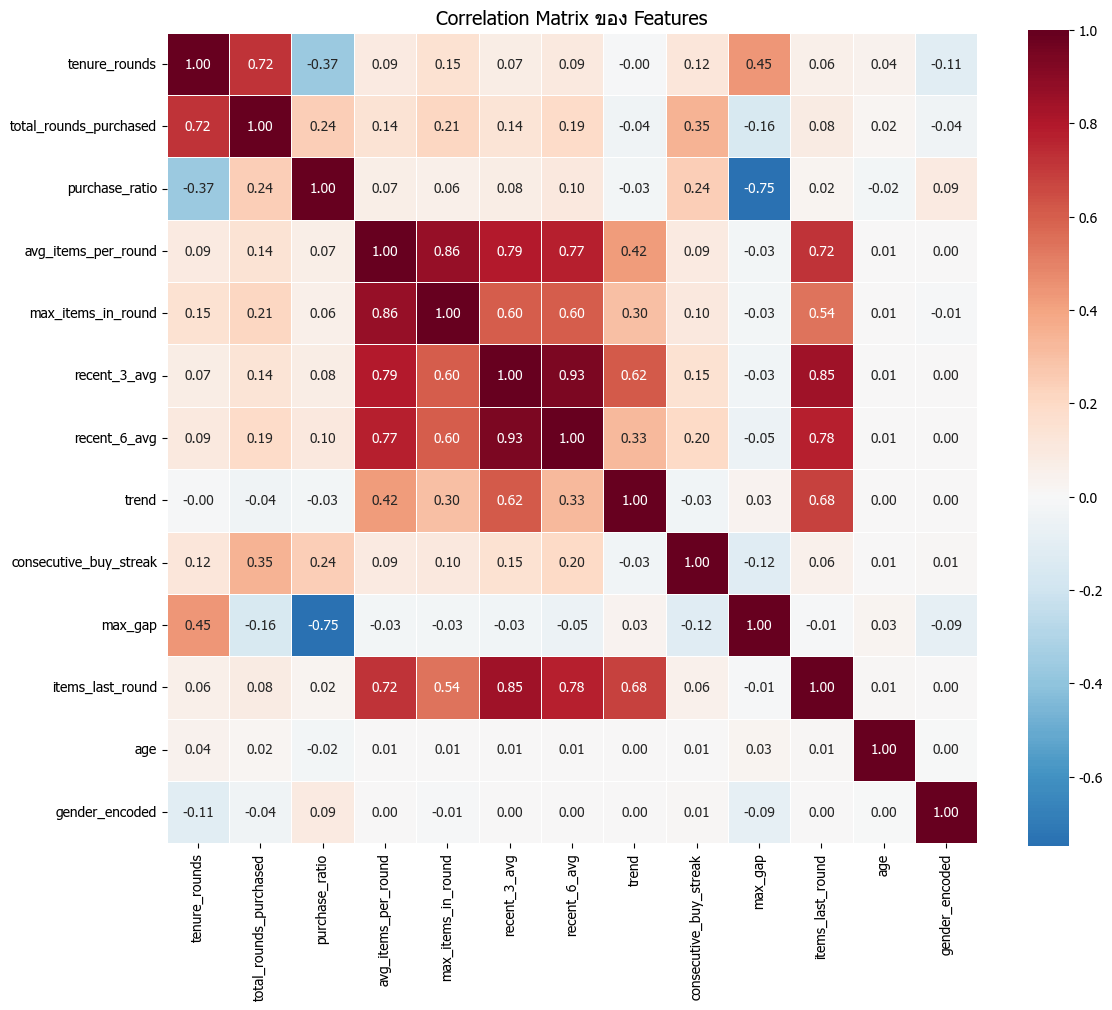

คู่ features ที่มี correlation สูง (|r| > 0.8):
  avg_items_per_round <-> max_items_in_round: 0.864
  recent_3_avg <-> recent_6_avg: 0.932
  recent_3_avg <-> items_last_round: 0.846


In [12]:
# ตรวจสอบ correlation
corr_matrix = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix ของ Features', fontsize=14)
plt.tight_layout()
plt.show()

# แสดงคู่ที่มี correlation สูง (> 0.8)
high_corr = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((feature_cols[i], feature_cols[j], corr_matrix.iloc[i, j]))

if high_corr:
    print('คู่ features ที่มี correlation สูง (|r| > 0.8):')
    for f1, f2, r in high_corr:
        print(f'  {f1} <-> {f2}: {r:.3f}')
else:
    print('ไม่มีคู่ features ที่มี correlation สูงกว่า 0.8')

In [13]:
# ตัด features ที่ซ้ำซ้อนสูง
drop_candidates = set()
for f1, f2, r in high_corr:
    # เก็บตัวที่ให้ข้อมูลกว้างกว่า
    if 'recent_3_avg' in (f1, f2):
        drop_candidates.add('recent_3_avg')
    elif 'max_items_in_round' in (f1, f2) and 'avg_items_per_round' in (f1, f2):
        drop_candidates.add('max_items_in_round')
    else:
        # ตัดตัวที่มี variance น้อยกว่า
        if df[f1].std() < df[f2].std():
            drop_candidates.add(f1)
        else:
            drop_candidates.add(f2)

features_for_clustering = [f for f in feature_cols if f not in drop_candidates]

if drop_candidates:
    print(f'ตัดออก: {drop_candidates}')
print(f'Features สำหรับ clustering ({len(features_for_clustering)} ตัว): {features_for_clustering}')

ตัดออก: {'recent_3_avg', 'max_items_in_round'}
Features สำหรับ clustering (11 ตัว): ['tenure_rounds', 'total_rounds_purchased', 'purchase_ratio', 'avg_items_per_round', 'recent_6_avg', 'trend', 'consecutive_buy_streak', 'max_gap', 'items_last_round', 'age', 'gender_encoded']


In [14]:
# Scale ด้วย RobustScaler (ทนทานต่อ outlier)
# ก่อน scale ให้ clip outlier ที่ percentile 99 เพื่อไม่ให้ค่าสุดโต่งครอบงำ clustering
X_raw = df[features_for_clustering].copy()

for col in features_for_clustering:
    upper = X_raw[col].quantile(0.99)
    X_raw[col] = X_raw[col].clip(upper=upper)
    
print('Clipped outliers at 99th percentile')

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_raw.values)

print(f'Scaled data shape: {X_scaled.shape}')

Clipped outliers at 99th percentile
Scaled data shape: (296351, 11)


Explained variance ratio: [0.949 0.025]
Total explained: 97.4%


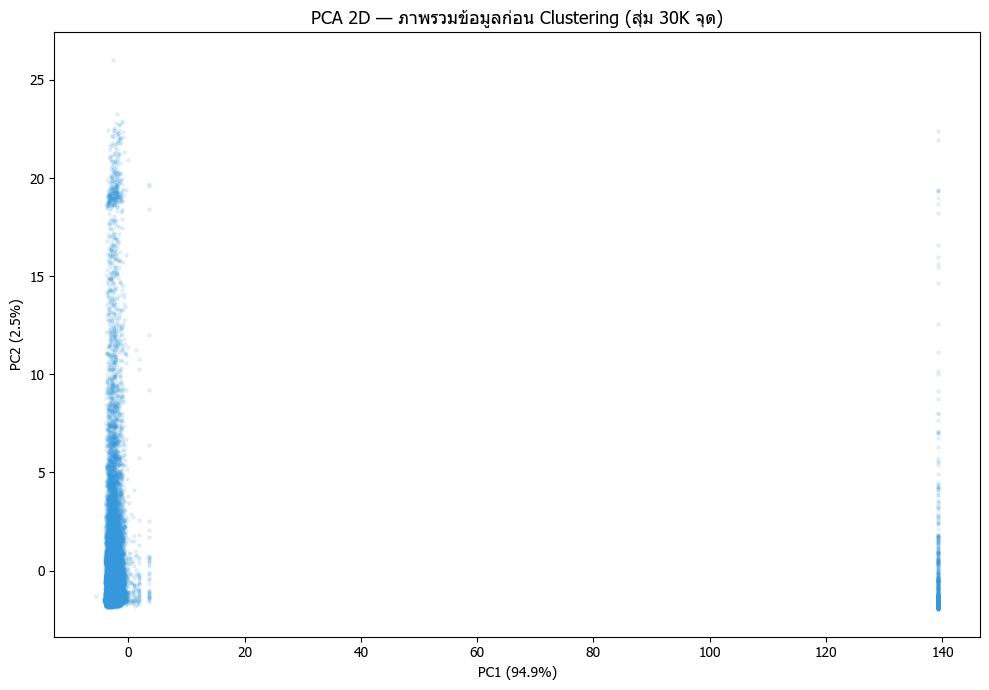

In [15]:
# PCA สำหรับ visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(3)}')
print(f'Total explained: {pca.explained_variance_ratio_.sum():.1%}')

fig, ax = plt.subplots(figsize=(10, 7))
# สุ่มข้อมูลเพื่อ plot (296K จุดจะหนักเกินไป)
sample_idx = np.random.RandomState(42).choice(len(X_pca), min(30000, len(X_pca)), replace=False)
ax.scatter(X_pca[sample_idx, 0], X_pca[sample_idx, 1], alpha=0.1, s=5, color='#3498db')
ax.set_title('PCA 2D — ภาพรวมข้อมูลก่อน Clustering (สุ่ม 30K จุด)', fontsize=13)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.tight_layout()
plt.show()

---
## 5. Clustering — K-Means
ใช้ K-Means เพราะ:
- ข้อมูล 296K rows → รันเร็ว scalable
- ผลลัพธ์อธิบายง่ายด้วย cluster center
- เหมาะกับ business presentation

In [16]:
# Elbow Method + Silhouette Score — ทดสอบ K = 2-12
K_range = range(2, 13)
inertias = []
silhouettes = []

# ใช้ sample สำหรับ silhouette (เร็วกว่า)
sample_size = min(30000, len(X_scaled))
sample_idx_sil = np.random.RandomState(42).choice(len(X_scaled), sample_size, replace=False)

for k in K_range:
    print(f'K={k}...', end=' ')
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

    # Silhouette Score (ใช้ sample)
    sil = silhouette_score(X_scaled[sample_idx_sil], km.labels_[sample_idx_sil])
    silhouettes.append(sil)
    print(f'Inertia={km.inertia_:,.0f}, Silhouette={sil:.4f}')

print('Done!')

K=2... 

Inertia=6,199,640, Silhouette=0.9656
K=3... 

Inertia=4,120,983, Silhouette=0.7208
K=4... 

Inertia=3,306,857, Silhouette=0.5098
K=5... 

Inertia=2,943,967, Silhouette=0.5149
K=6... 

...

Inertia=2,269,885, Silhouette=0.2881
K=9... 

Inertia=2,095,767, Silhouette=0.1818
K=10... 

Inertia=1,972,017, Silhouette=0.1843
K=11... 

Inertia=1,871,737, Silhouette=0.1912
K=12... 

Inertia=1,806,838, Silhouette=0.1903
Done!


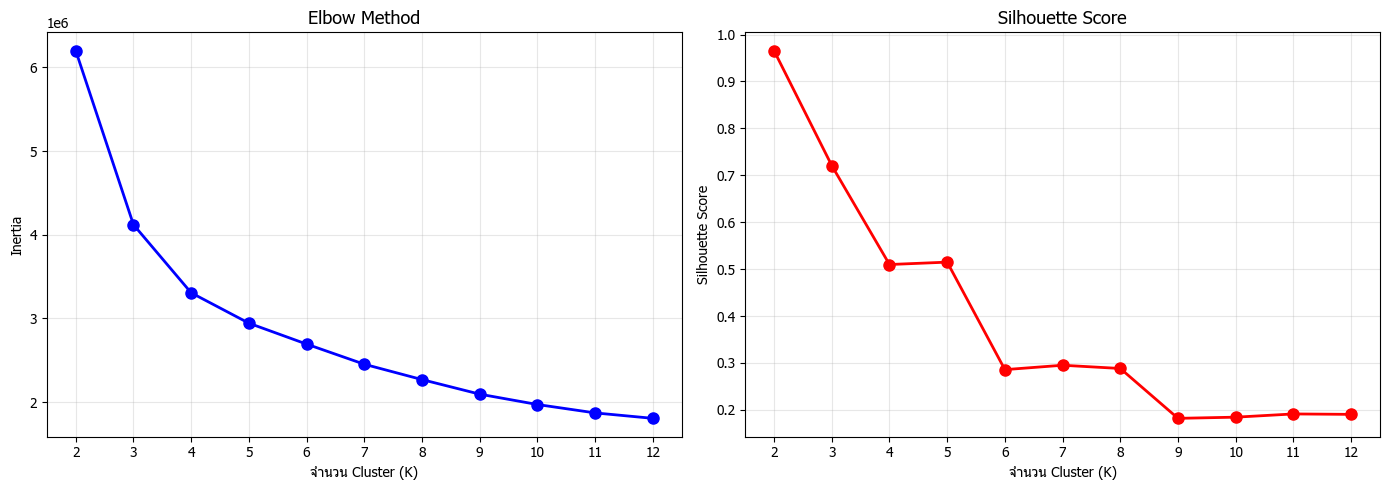


Silhouette Score สูงสุดที่ K = 2 (0.9656)
พิจารณา Elbow + Silhouette ร่วมกันเพื่อเลือก K ที่เหมาะสม


In [17]:
# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', markersize=8, linewidth=2)
axes[0].set_title('Elbow Method', fontsize=13)
axes[0].set_xlabel('จำนวน Cluster (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(K_range))
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 'ro-', markersize=8, linewidth=2)
axes[1].set_title('Silhouette Score', fontsize=13)
axes[1].set_xlabel('จำนวน Cluster (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(K_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# แนะนำ K
best_k_sil = list(K_range)[np.argmax(silhouettes)]
print(f'\nSilhouette Score สูงสุดที่ K = {best_k_sil} ({max(silhouettes):.4f})')
print('พิจารณา Elbow + Silhouette ร่วมกันเพื่อเลือก K ที่เหมาะสม')

In [18]:
# เลือก K ที่เหมาะสม
# K น้อย (2-4) จะได้กลุ่มใหญ่ 1 กลุ่ม (85%+) ซึ่งภาพกว้างเกินไป
# เพิ่ม K ให้มากขึ้นเพื่อแตกกลุ่มใหญ่ออก → เห็นกลุ่มย่อยที่น่าสนใจ

optimal_k = 8
print(f'เลือก K = {optimal_k}')
print(f'Silhouette Score ที่ K={optimal_k}: {silhouettes[optimal_k - 2]:.4f}')
print()
print('เหตุผล: K สูงขึ้นจะแตกกลุ่มใหญ่ออก ทำให้เห็นกลุ่มย่อยที่น่าสนใจ')
print('เช่น ลูกค้าใหม่ซื้อครั้งเดียว, ลูกค้าที่ซื้อน้อยลงเรื่อยๆ, ลูกค้า VIP ที่หยุดทันที')

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10, max_iter=300)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f'\nจำนวนลูกค้าในแต่ละ cluster:')
cluster_counts = df['cluster'].value_counts().sort_index()
for c, count in cluster_counts.items():
    print(f'  Cluster {c}: {count:>8,} คน ({count/len(df)*100:.1f}%)')

เลือก K = 8
Silhouette Score ที่ K=8: 0.2881

เหตุผล: K สูงขึ้นจะแตกกลุ่มใหญ่ออก ทำให้เห็นกลุ่มย่อยที่น่าสนใจ
เช่น ลูกค้าใหม่ซื้อครั้งเดียว, ลูกค้าที่ซื้อน้อยลงเรื่อยๆ, ลูกค้า VIP ที่หยุดทันที



จำนวนลูกค้าในแต่ละ cluster:
  Cluster 0:  200,529 คน (67.7%)
  Cluster 1:    5,645 คน (1.9%)
  Cluster 2:    6,004 คน (2.0%)
  Cluster 3:   56,094 คน (18.9%)
  Cluster 4:    8,742 คน (2.9%)
  Cluster 5:   13,119 คน (4.4%)
  Cluster 6:    6,111 คน (2.1%)
  Cluster 7:      107 คน (0.0%)


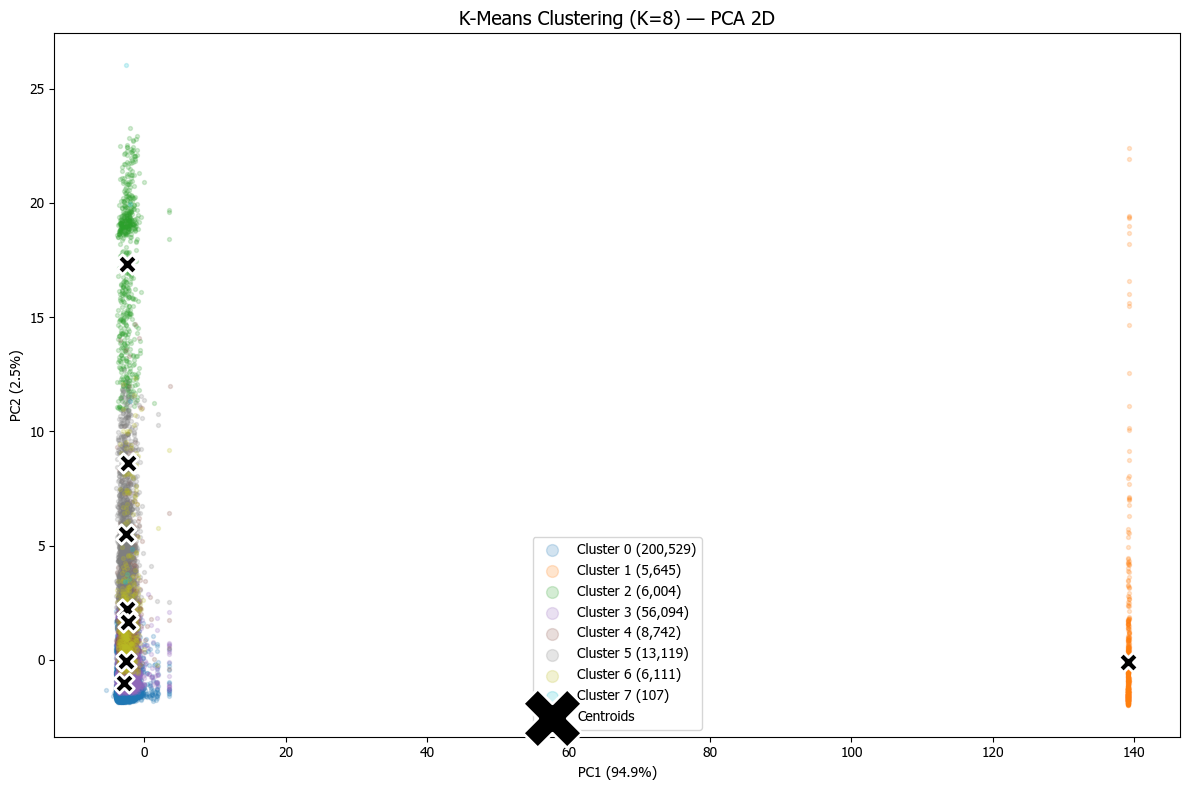

In [19]:
# PCA 2D scatter plot แยกสีตาม cluster
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
sample_idx_plot = np.random.RandomState(42).choice(len(X_pca), min(30000, len(X_pca)), replace=False)

for c in range(optimal_k):
    mask = (df['cluster'].values[sample_idx_plot] == c)
    ax.scatter(X_pca[sample_idx_plot][mask, 0], X_pca[sample_idx_plot][mask, 1],
              alpha=0.2, s=8, color=colors[c], label=f'Cluster {c} ({cluster_counts[c]:,})')

# Plot centroids
centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
          marker='X', s=200, c='black', edgecolors='white', linewidths=2, zorder=5, label='Centroids')

ax.set_title(f'K-Means Clustering (K={optimal_k}) — PCA 2D', fontsize=14)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=10, markerscale=3)
plt.tight_layout()
plt.show()

---
## 6. Cluster Profiling & Interpretation
สรุปลักษณะเด่นของแต่ละ cluster

In [20]:
# สรุปค่าเฉลี่ยของแต่ละ feature ในแต่ละ cluster
cluster_profile = df.groupby('cluster')[feature_cols].mean()
cluster_profile['count'] = df.groupby('cluster').size()
cluster_profile['pct'] = (cluster_profile['count'] / len(df) * 100).round(1)

print('=== Cluster Profile (ค่าเฉลี่ย) ===')
cluster_profile.round(2)

=== Cluster Profile (ค่าเฉลี่ย) ===


,tenure_rounds,total_rounds_purchased,purchase_ratio,avg_items_per_round,max_items_in_round,recent_3_avg,recent_6_avg,trend,consecutive_buy_streak,max_gap,items_last_round,age,gender_encoded,count,pct
cluster,,,,,,,,,,,,,,,
0,30.93,12.99,0.50,3.59,7.90,1.68,1.37,0.26,1.36,8.47,3.20,37.22,0.62,200529,67.7
1,38.07,17.05,0.48,6.75,17.66,4.27,3.42,0.65,2.37,9.76,6.93,2025.00,0.64,5645,1.9
2,46.24,38.99,0.86,12.34,38.91,10.65,10.85,-0.12,25.53,3.44,9.98,42.31,0.65,6004,2.0
3,37.75,18.03,0.53,9.28,23.73,6.01,4.00,1.43,1.81,8.48,10.22,41.08,0.63,56094,18.9
4,38.92,21.20,0.59,32.82,96.78,26.06,17.26,6.03,2.49,7.43,40.10,41.85,0.64,8742,2.9
5,37.43,25.00,0.72,6.21,17.40,6.06,5.97,0.11,7.56,5.46,5.53,39.96,0.68,13119,4.4
6,42.74,28.12,0.67,23.17,77.11,10.12,14.42,-2.56,2.09,5.59,12.70,43.25,0.62,6111,2.1
7,41.81,27.34,0.68,133.88,449.96,59.84,117.05,-35.65,7.32,5.42,59.75,43.85,0.65,107,0.0


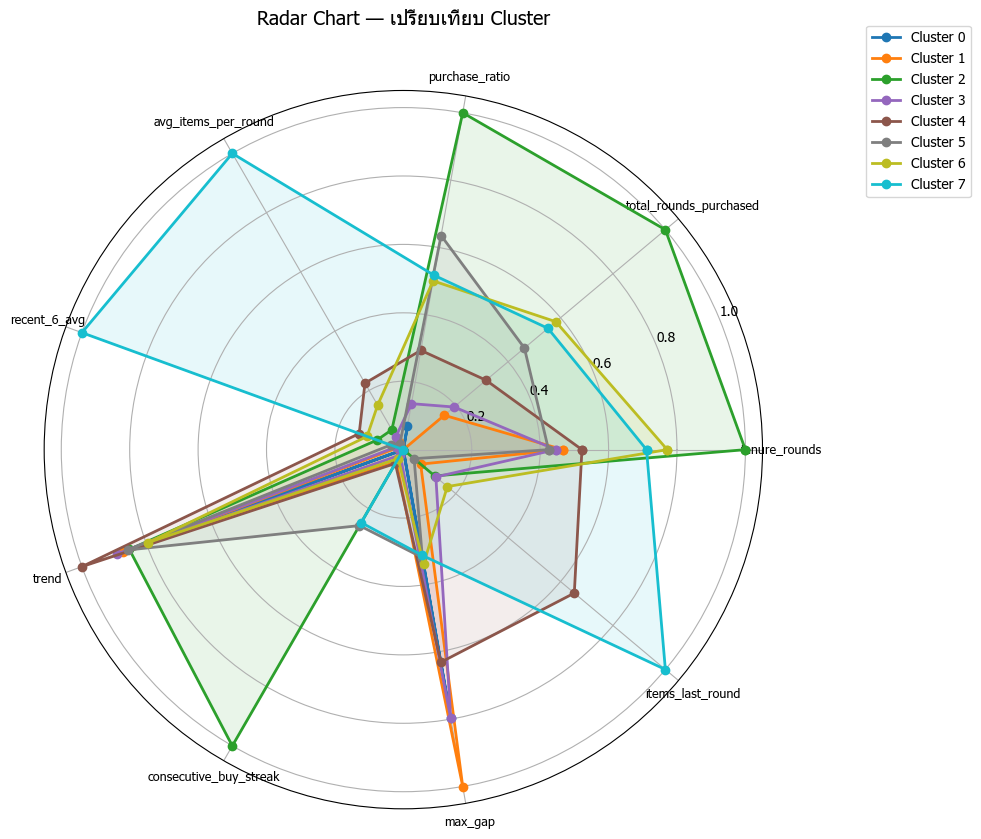

In [21]:
# Radar Chart เปรียบเทียบ clusters
from math import pi

# เลือก features หลักสำหรับ radar chart
radar_features = ['tenure_rounds', 'total_rounds_purchased', 'purchase_ratio',
                  'avg_items_per_round', 'recent_6_avg', 'trend',
                  'consecutive_buy_streak', 'max_gap', 'items_last_round']

# Normalize สำหรับ radar chart (0-1)
profile_norm = cluster_profile[radar_features].copy()
for col in radar_features:
    col_min = profile_norm[col].min()
    col_max = profile_norm[col].max()
    if col_max > col_min:
        profile_norm[col] = (profile_norm[col] - col_min) / (col_max - col_min)
    else:
        profile_norm[col] = 0.5

# Plot radar
n_features = len(radar_features)
angles = [n / float(n_features) * 2 * pi for n in range(n_features)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for c in range(optimal_k):
    values = profile_norm.loc[c].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {c}', color=colors[c])
    ax.fill(angles, values, alpha=0.1, color=colors[c])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=9)
ax.set_title('Radar Chart — เปรียบเทียบ Cluster', fontsize=14, y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.tight_layout()
plt.show()

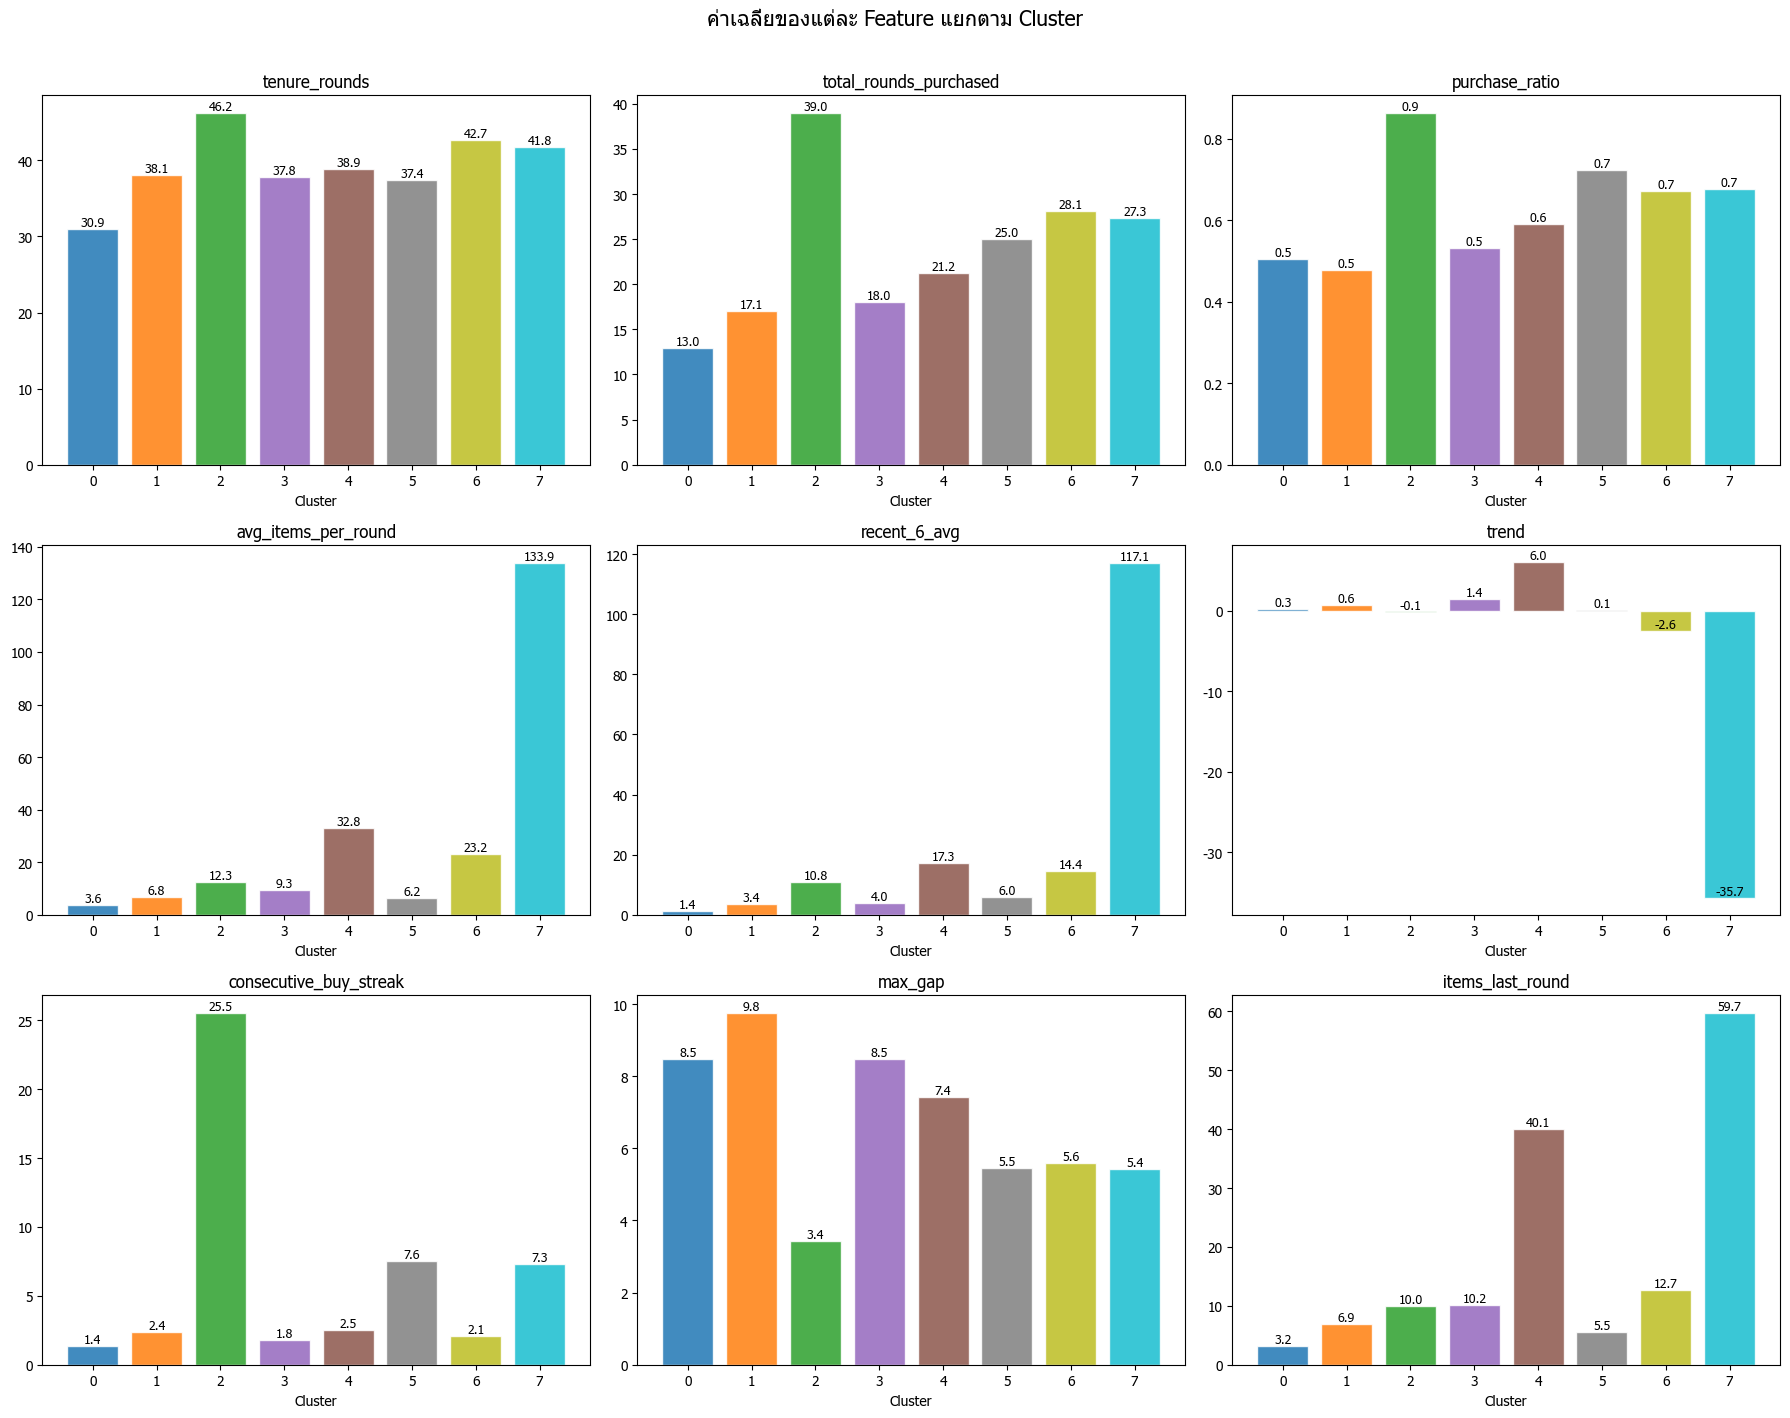

In [22]:
# Grouped bar chart เปรียบเทียบ features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feat in enumerate(radar_features):
    ax = axes[i]
    means = cluster_profile[feat]
    bars = ax.bar(range(optimal_k), means.values, color=[colors[c] for c in range(optimal_k)],
                 edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontsize=12)
    ax.set_xlabel('Cluster')
    ax.set_xticks(range(optimal_k))
    for bar_item, val in zip(bars, means.values):
        ax.text(bar_item.get_x() + bar_item.get_width()/2., bar_item.get_height(),
               f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('ค่าเฉลี่ยของแต่ละ Feature แยกตาม Cluster', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [23]:
# ตั้งชื่อ cluster ตามพฤติกรรม
print('=== การตั้งชื่อ Cluster ===\n')

cluster_names = {}
for c in range(optimal_k):
    p = cluster_profile.loc[c]
    tenure = p['tenure_rounds']
    total_buy = p['total_rounds_purchased']
    ratio = p['purchase_ratio']
    avg_item = p['avg_items_per_round']
    trend_val = p['trend']
    streak = p['consecutive_buy_streak']
    last_item = p['items_last_round']

    # ตั้งชื่อตามลักษณะเด่น
    traits = []
    if tenure <= cluster_profile['tenure_rounds'].quantile(0.33):
        traits.append('ลูกค้าใหม่')
    elif tenure >= cluster_profile['tenure_rounds'].quantile(0.66):
        traits.append('ลูกค้าเก่า')
    else:
        traits.append('ลูกค้าระยะกลาง')

    if total_buy <= 2:
        traits.append('ซื้อน้อยมาก')
    elif avg_item >= cluster_profile['avg_items_per_round'].quantile(0.66):
        traits.append('ซื้อมาก')
    else:
        traits.append('ซื้อปานกลาง')

    if trend_val < -0.1:
        traits.append('แนวโน้มลดลง')
    elif trend_val > 0.1:
        traits.append('แนวโน้มเพิ่มขึ้น')

    name = ' / '.join(traits)
    cluster_names[c] = name
    print(f'Cluster {c}: {name}')
    print(f'  tenure={tenure:.1f} งวด, ซื้อ={total_buy:.1f} งวด, ratio={ratio:.2f}, '
          f'avg={avg_item:.1f} ใบ, trend={trend_val:.3f}, streak={streak:.1f}, last={last_item:.1f}')
    print(f'  จำนวน: {cluster_counts[c]:,} คน ({cluster_counts[c]/len(df)*100:.1f}%)')
    print()

=== การตั้งชื่อ Cluster ===

Cluster 0: ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น
  tenure=30.9 งวด, ซื้อ=13.0 งวด, ratio=0.50, avg=3.6 ใบ, trend=0.261, streak=1.4, last=3.2
  จำนวน: 200,529 คน (67.7%)

Cluster 1: ลูกค้าระยะกลาง / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น
  tenure=38.1 งวด, ซื้อ=17.1 งวด, ratio=0.48, avg=6.8 ใบ, trend=0.647, streak=2.4, last=6.9
  จำนวน: 5,645 คน (1.9%)

Cluster 2: ลูกค้าเก่า / ซื้อปานกลาง / แนวโน้มลดลง
  tenure=46.2 งวด, ซื้อ=39.0 งวด, ratio=0.86, avg=12.3 ใบ, trend=-0.124, streak=25.5, last=10.0
  จำนวน: 6,004 คน (2.0%)

Cluster 3: ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น
  tenure=37.8 งวด, ซื้อ=18.0 งวด, ratio=0.53, avg=9.3 ใบ, trend=1.428, streak=1.8, last=10.2
  จำนวน: 56,094 คน (18.9%)

Cluster 4: ลูกค้าระยะกลาง / ซื้อมาก / แนวโน้มเพิ่มขึ้น
  tenure=38.9 งวด, ซื้อ=21.2 งวด, ratio=0.59, avg=32.8 ใบ, trend=6.026, streak=2.5, last=40.1
  จำนวน: 8,742 คน (2.9%)

Cluster 5: ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น
  tenure=37.4 งวด, ซื้อ=25.0 งวด, ratio=

### ตัวอย่างข้อมูลการซื้อรายงวด (Purchase Array) ของแต่ละ Cluster
แสดงจำนวนใบที่ซื้อในแต่ละงวด เรียงจากงวดแรกที่ซื้อถึงงวดล่าสุด (2026-02-16)  
เพื่อดูรูปแบบการซื้อของลูกค้าแต่ละกลุ่ม

In [24]:
# แสดง Purchase Array ของแต่ละ Cluster
# เอาค่าแต่ละงวดมาเรียงเป็น array ตั้งแต่งวดแรกที่ซื้อ ถึง 2026-02-16

# สร้าง array สำหรับแต่ละลูกค้า (เฉพาะงวดที่เป็นสมาชิก — ตัด null ด้านหน้าออก)
def make_purchase_array(row_idx):
    """สร้าง purchase array ตั้งแต่งวดแรกที่ซื้อ"""
    first_idx = int(first_idxs[row_idx])
    arr = purchase_matrix[row_idx, first_idx:].astype(int).tolist()
    return arr

# แสดงตัวอย่างแต่ละ cluster
n_sample = 50  # จำนวนตัวอย่างต่อ cluster

for c in range(optimal_k):
    cluster_idx = df[df['cluster'] == c].index
    count = len(cluster_idx)
    name = cluster_names.get(c, '')
    
    print('=' * 70)
    print(f'Cluster {c} | {count:,} คน | {name}')
    print('=' * 70)
    
    # สุ่มตัวอย่าง
    sample_size_c = min(n_sample, count)
    sample_indices = np.random.RandomState(c).choice(cluster_idx, sample_size_c, replace=False)
    
    # สร้าง DataFrame แสดงผล
    sample_data = []
    for idx in sample_indices:
        arr = make_purchase_array(idx)
        sample_data.append({'purchase_array': arr})
    
    sample_df = pd.DataFrame(sample_data)
    display(sample_df)
    print()

Cluster 0 | 200,529 คน | ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น


,purchase_array
0,"[3, 0, 0, 6, 2, 0, 0, 1, 0, 0, 0, 0, 0, 0, 3, ..."
1,"[3, 1, 2, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 3, 0, ..."
2,"[2, 4, 2, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 4]"
3,"[3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 5, 0, 0, 0, 0, ..."
5,"[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,[4]
7,"[1, 6, 4, 3]"
8,"[9, 7, 0, 2, 0, 0, 4, 10, 17, 8, 0, 8]"
9,"[1, 11, 8, 5, 5, 16, 17, 8, 0, 0, 2, 0, 0, 5, ..."



Cluster 1 | 5,645 คน | ลูกค้าระยะกลาง / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น


,purchase_array
0,"[1, 12, 4, 2, 3, 0, 4, 0, 2, 0, 1, 0, 0, 0, 3,..."
1,"[1, 15, 0, 15, 10, 4, 4, 3, 4, 3, 11, 3, 14, 2..."
2,"[1, 0, 0, 0, 0, 6, 6, 0, 0, 4, 6, 1, 0, 1, 5, ..."
3,"[9, 36, 10, 0, 0, 0, 0, 5, 0, 8, 0, 0, 0, 0, 0..."
4,"[8, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
5,"[9, 0, 0, 0, 6, 0, 9, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6,"[2, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 3, 3, 5]"
7,[4]
8,"[3, 0, 0, 0, 3, 0, 0, 0, 0, 5, 0, 0, 0, 3, 0, ..."
9,"[1, 0, 1, 0, 0, 3, 0, 0, 1, 0, 0, 1, 0, 1, 0, ..."



Cluster 2 | 6,004 คน | ลูกค้าเก่า / ซื้อปานกลาง / แนวโน้มลดลง


...

,purchase_array
0,"[7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 19, 31, 13, 2, ..."
1,"[1, 2, 4, 1, 1, 3]"
2,"[16, 0, 6, 8, 0, 14, 13, 0, 16, 20, 8, 13, 8, ..."
3,"[18, 7, 24, 4, 10, 9, 5, 15]"
4,"[5, 22, 8, 4, 3]"
5,"[6, 9, 5, 11, 6]"
6,"[3, 0, 0, 0, 3, 0, 5, 0, 0, 0, 4, 2, 2, 5, 0, ..."
7,"[1, 1, 0, 0, 0, 0, 0, 0, 1, 3, 2, 3, 2]"
8,"[3, 0, 3, 15, 4, 12, 9, 2, 2, 4, 0, 9, 0, 25, ..."
9,"[2, 0, 2, 2, 2, 4, 6, 6, 3, 4, 4, 4]"



Cluster 6 | 6,111 คน | ลูกค้าเก่า / ซื้อมาก / แนวโน้มลดลง


,purchase_array
0,"[19, 52, 76, 0, 50, 9]"
1,"[12, 0, 13, 10, 0, 11, 9, 0, 8, 0, 28, 0, 0, 0..."
2,"[21, 15, 10, 10, 0, 0, 17]"
3,"[63, 23, 46, 0, 0, 5, 50, 0, 0, 25, 22, 3, 3, ..."
4,"[8, 7, 14, 6, 15, 0, 6, 10, 2, 16, 10, 0, 0, 2..."
5,"[7, 14, 55, 30, 55, 23, 11, 17, 18, 41]"
6,"[8, 19, 45, 24, 36, 9, 12, 15, 8, 0, 11, 0, 10..."
7,"[30, 50, 0, 33, 16, 25, 17, 34, 18, 35, 53, 41..."
8,"[6, 12, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
9,"[9, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."



Cluster 7 | 107 คน | ลูกค้าเก่า / ซื้อมาก / แนวโน้มลดลง


,purchase_array
0,"[10, 30, 44, 163, 0, 0, 0, 0, 20, 205, 60, 150..."
1,"[18, 0, 119, 0, 12, 0, 69, 0, 0, 0, 0, 0, 19, ..."
2,"[156, 396, 583, 452, 544, 408, 417, 68, 25, 24..."
3,"[1, 4, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, ..."
4,"[10, 10, 0, 0, 14, 0, 0, 49, 0, 65, 67, 86, 12..."
5,"[22, 25, 23, 17, 0, 0, 0, 0, 199, 0, 0, 25, 0,..."
6,"[4, 10, 2, 10, 0, 0, 2, 0, 0, 0, 0, 0, 5, 0, 0..."
7,"[11, 0, 0, 0, 0, 10, 0, 0, 0, 0, 5, 0, 4, 4, 0..."
8,"[33, 0, 105, 70, 134, 133, 240, 99, 308, 188, ..."
9,"[55, 60, 0, 0, 33, 0, 0, 125, 88, 0, 0, 74, 25..."


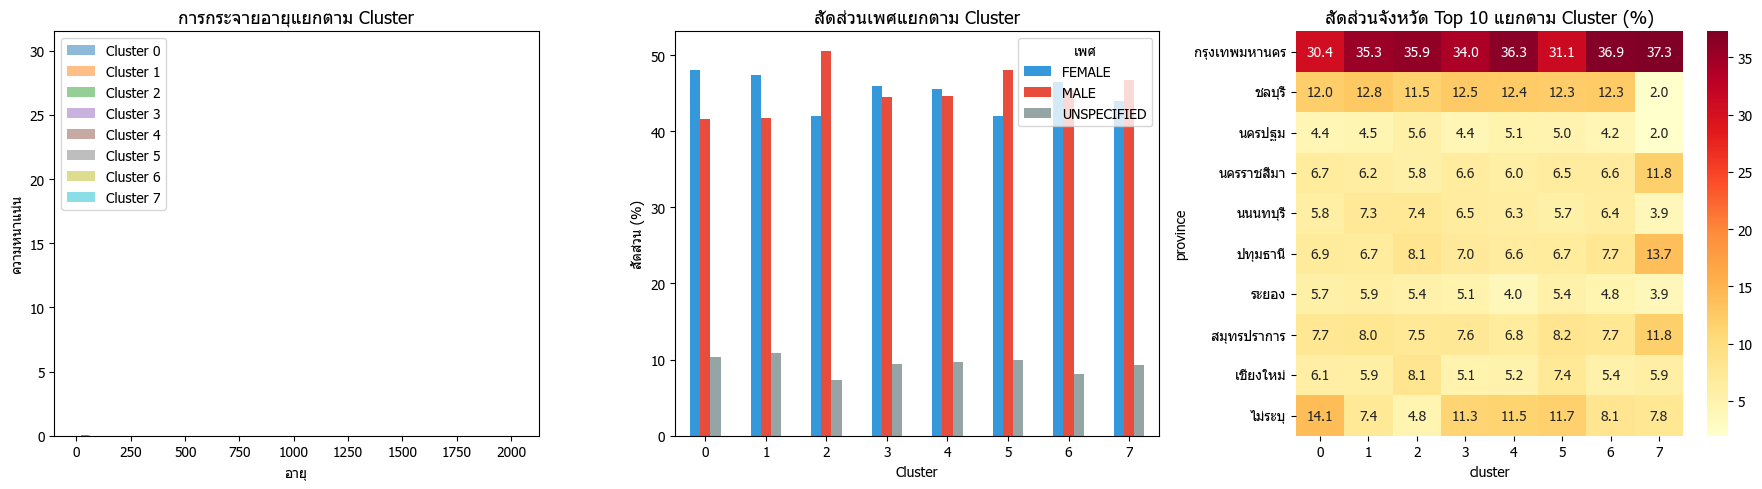

In [25]:
# Demographic breakdown ของแต่ละ cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution by cluster
for c in range(optimal_k):
    axes[0].hist(df[df['cluster'] == c]['age'], bins=30, alpha=0.5,
                label=f'Cluster {c}', color=colors[c], density=True)
axes[0].set_title('การกระจายอายุแยกตาม Cluster', fontsize=13)
axes[0].set_xlabel('อายุ')
axes[0].set_ylabel('ความหนาแน่น')
axes[0].legend()

# Gender by cluster
gender_cluster = pd.crosstab(df['cluster'], df['gender'], normalize='index') * 100
gender_cluster.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#95a5a6'][:len(gender_cluster.columns)])
axes[1].set_title('สัดส่วนเพศแยกตาม Cluster', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('สัดส่วน (%)')
axes[1].legend(title='เพศ')
axes[1].tick_params(axis='x', rotation=0)

# Top provinces by cluster (heatmap)
top_prov = df['province'].value_counts().head(10).index
prov_cluster = pd.crosstab(df[df['province'].isin(top_prov)]['province'],
                           df[df['province'].isin(top_prov)]['cluster'],
                           normalize='columns') * 100
sns.heatmap(prov_cluster, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[2])
axes[2].set_title('สัดส่วนจังหวัด Top 10 แยกตาม Cluster (%)', fontsize=13)

plt.tight_layout()
plt.show()

---
## 7. Churn Warning Signals — สัญญาณเตือน
วิเคราะห์สัญญาณเตือนที่ควรระวังในงวดถัดไป

In [26]:
# กลุ่มที่มีจำนวนมากที่สุด = กลุ่มเสี่ยงสูงสุด
print('=== จำนวนลูกค้าแต่ละ Cluster (เรียงจากมากไปน้อย) ===\n')
for c in cluster_counts.sort_values(ascending=False).index:
    name = cluster_names.get(c, f'Cluster {c}')
    count = cluster_counts[c]
    pct = count / len(df) * 100
    risk = '*** กลุ่มเสี่ยงสูงสุด ***' if c == cluster_counts.idxmax() else ''
    print(f'  Cluster {c} ({name}): {count:>8,} คน ({pct:.1f}%) {risk}')

=== จำนวนลูกค้าแต่ละ Cluster (เรียงจากมากไปน้อย) ===

  Cluster 0 (ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น):  200,529 คน (67.7%) *** กลุ่มเสี่ยงสูงสุด ***
  Cluster 3 (ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น):   56,094 คน (18.9%) 
  Cluster 5 (ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น):   13,119 คน (4.4%) 
  Cluster 4 (ลูกค้าระยะกลาง / ซื้อมาก / แนวโน้มเพิ่มขึ้น):    8,742 คน (2.9%) 
  Cluster 6 (ลูกค้าเก่า / ซื้อมาก / แนวโน้มลดลง):    6,111 คน (2.1%) 
  Cluster 2 (ลูกค้าเก่า / ซื้อปานกลาง / แนวโน้มลดลง):    6,004 คน (2.0%) 
  Cluster 1 (ลูกค้าระยะกลาง / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น):    5,645 คน (1.9%) 
  Cluster 7 (ลูกค้าเก่า / ซื้อมาก / แนวโน้มลดลง):      107 คน (0.0%) 


In [27]:
# สัญญาณเตือนจากแต่ละ cluster
print('=== สัญญาณเตือนที่ควรระวังในงวดถัดไป ===\n')

warning_signals = []

for c in range(optimal_k):
    p = cluster_profile.loc[c]
    signals = []

    # สัญญาณ 1: ลูกค้าใหม่ซื้อแค่ 1-2 งวด
    if p['total_rounds_purchased'] <= 3 and p['tenure_rounds'] <= 5:
        signals.append('ลูกค้าใหม่ที่ซื้อแค่ 1-2 งวด -> เสี่ยง churn สูงมาก')

    # สัญญาณ 2: trend ลดลงต่อเนื่อง
    if p['trend'] < -0.1:
        signals.append(f"แนวโน้มซื้อลดลงต่อเนื่อง (trend = {p['trend']:.3f})")

    # สัญญาณ 3: purchase ratio ต่ำ (ซื้อไม่สม่ำเสมอ)
    if p['purchase_ratio'] < 0.3:
        signals.append(f"ซื้อไม่สม่ำเสมอ (purchase_ratio = {p['purchase_ratio']:.2f})")

    # สัญญาณ 4: max_gap สูง
    if p['max_gap'] > 5:
        signals.append(f"เคยหยุดซื้อนาน (max_gap = {p['max_gap']:.1f} งวด)")

    # สัญญาณ 5: recent avg ต่ำกว่า overall avg
    if p['recent_6_avg'] < p['avg_items_per_round'] * 0.5:
        signals.append('ซื้อน้อยลงจากค่าเฉลี่ยปกติ (recent_6_avg ต่ำ)')

    # สัญญาณ 6: streak สั้น
    if p['consecutive_buy_streak'] <= 1 and p['tenure_rounds'] > 5:
        signals.append('ไม่ได้ซื้อติดต่อกัน (streak สั้น) -> ไม่มี engagement')

    warning_signals.append({
        'cluster': c,
        'name': cluster_names.get(c, ''),
        'count': cluster_counts[c],
        'signals': signals
    })

    print(f'Cluster {c} -- {cluster_names.get(c, "")} ({cluster_counts[c]:,} คน):')
    if signals:
        for s in signals:
            print(f'  >> {s}')
    else:
        print('  (i) ไม่มีสัญญาณเตือนเด่นชัด -- อาจ churn จากปัจจัยภายนอก')
    print()

=== สัญญาณเตือนที่ควรระวังในงวดถัดไป ===

Cluster 0 -- ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น (200,529 คน):
  >> เคยหยุดซื้อนาน (max_gap = 8.5 งวด)
  >> ซื้อน้อยลงจากค่าเฉลี่ยปกติ (recent_6_avg ต่ำ)

Cluster 1 -- ลูกค้าระยะกลาง / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น (5,645 คน):
  >> เคยหยุดซื้อนาน (max_gap = 9.8 งวด)

Cluster 2 -- ลูกค้าเก่า / ซื้อปานกลาง / แนวโน้มลดลง (6,004 คน):
  >> แนวโน้มซื้อลดลงต่อเนื่อง (trend = -0.124)

Cluster 3 -- ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น (56,094 คน):
  >> เคยหยุดซื้อนาน (max_gap = 8.5 งวด)
  >> ซื้อน้อยลงจากค่าเฉลี่ยปกติ (recent_6_avg ต่ำ)

Cluster 4 -- ลูกค้าระยะกลาง / ซื้อมาก / แนวโน้มเพิ่มขึ้น (8,742 คน):
  >> เคยหยุดซื้อนาน (max_gap = 7.4 งวด)

Cluster 5 -- ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น (13,119 คน):
  >> เคยหยุดซื้อนาน (max_gap = 5.5 งวด)

Cluster 6 -- ลูกค้าเก่า / ซื้อมาก / แนวโน้มลดลง (6,111 คน):
  >> แนวโน้มซื้อลดลงต่อเนื่อง (trend = -2.560)
  >> เคยหยุดซื้อนาน (max_gap = 5.6 งวด)

Cluster 7 -- ลูกค้าเก่า / ซื้อมาก / แน

In [28]:
# ตาราง Actionable Insights
insights_data = []

for ws in warning_signals:
    c = ws['cluster']
    p = cluster_profile.loc[c]

    # กำหนด action ตามลักษณะ cluster
    if p['tenure_rounds'] <= 5 and p['total_rounds_purchased'] <= 3:
        action = 'Welcome Campaign -- ส่งโปรโมชันดึงดูดลูกค้าใหม่ให้กลับมาซื้อ'
        priority = 'สูง'
    elif p['trend'] < -0.1 and p['tenure_rounds'] > 10:
        action = 'Retention Program -- ติดต่อลูกค้าเก่าที่เริ่มห่าง เสนอสิทธิพิเศษ'
        priority = 'สูง'
    elif p['avg_items_per_round'] >= cluster_profile['avg_items_per_round'].quantile(0.66):
        action = 'VIP Win-back -- ลูกค้าซื้อมากแต่หยุดทันที ต้องติดต่อด่วน'
        priority = 'สูงมาก'
    elif p['purchase_ratio'] < 0.3:
        action = 'Re-engagement -- ส่ง reminder ก่อนงวดถัดไป'
        priority = 'กลาง'
    else:
        action = 'General Campaign -- ส่งโปรโมชันทั่วไป'
        priority = 'ปกติ'

    insights_data.append({
        'Cluster': c,
        'ชื่อกลุ่ม': ws['name'],
        'จำนวน': f"{ws['count']:,}",
        'สัดส่วน': f"{ws['count']/len(df)*100:.1f}%",
        'ระดับความสำคัญ': priority,
        'แนวทางปฏิบัติ': action
    })

insights_df = pd.DataFrame(insights_data)
print('=== ตาราง Actionable Insights ===')
insights_df

=== ตาราง Actionable Insights ===


,Cluster,ชื่อกลุ่ม,จำนวน,สัดส่วน,ระดับความสำคัญ,แนวทางปฏิบัติ
0,0,ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น,"200,529",67.7%,ปกติ,General Campaign -- ส่งโปรโมชันทั่วไป
1,1,ลูกค้าระยะกลาง / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น,"5,645",1.9%,ปกติ,General Campaign -- ส่งโปรโมชันทั่วไป
2,2,ลูกค้าเก่า / ซื้อปานกลาง / แนวโน้มลดลง,"6,004",2.0%,สูง,Retention Program -- ติดต่อลูกค้าเก่าที่เริ่มห...
3,3,ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น,"56,094",18.9%,ปกติ,General Campaign -- ส่งโปรโมชันทั่วไป
4,4,ลูกค้าระยะกลาง / ซื้อมาก / แนวโน้มเพิ่มขึ้น,"8,742",2.9%,สูงมาก,VIP Win-back -- ลูกค้าซื้อมากแต่หยุดทันที ต้อง...
5,5,ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น,"13,119",4.4%,ปกติ,General Campaign -- ส่งโปรโมชันทั่วไป
6,6,ลูกค้าเก่า / ซื้อมาก / แนวโน้มลดลง,"6,111",2.1%,สูง,Retention Program -- ติดต่อลูกค้าเก่าที่เริ่มห...
7,7,ลูกค้าเก่า / ซื้อมาก / แนวโน้มลดลง,107,0.0%,สูง,Retention Program -- ติดต่อลูกค้าเก่าที่เริ่มห...


---
## 8. Summary & Recommendations

In [29]:
# สรุปภาพรวม
print('=' * 70)
print('สรุปผลการวิเคราะห์ Churn Customer Analysis')
print('=' * 70)
print(f'\nจำนวนลูกค้าที่ Churn ทั้งหมด: {len(df):,} คน')
print(f'จำนวน Cluster: {optimal_k} กลุ่ม')
print(f'Features ที่ใช้: {len(features_for_clustering)} ตัว')
print(f'Silhouette Score: {silhouettes[optimal_k - 2]:.4f}')
print(f'\n--- รายละเอียดแต่ละ Cluster ---')

for c in range(optimal_k):
    p = cluster_profile.loc[c]
    print(f'\n[Cluster {c}] {cluster_names.get(c, "")}')
    print(f'  จำนวน: {cluster_counts[c]:,} คน ({cluster_counts[c]/len(df)*100:.1f}%)')
    print(f'  Tenure เฉลี่ย: {p["tenure_rounds"]:.1f} งวด')
    print(f'  งวดที่ซื้อเฉลี่ย: {p["total_rounds_purchased"]:.1f} งวด')
    print(f'  สัดส่วนการซื้อ: {p["purchase_ratio"]:.2f}')
    print(f'  ใบเฉลี่ยต่องวด: {p["avg_items_per_round"]:.1f}')
    print(f'  แนวโน้ม (trend): {p["trend"]:.3f}')

สรุปผลการวิเคราะห์ Churn Customer Analysis

จำนวนลูกค้าที่ Churn ทั้งหมด: 296,351 คน
จำนวน Cluster: 8 กลุ่ม
Features ที่ใช้: 11 ตัว
Silhouette Score: 0.2881

--- รายละเอียดแต่ละ Cluster ---

[Cluster 0] ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น
  จำนวน: 200,529 คน (67.7%)
  Tenure เฉลี่ย: 30.9 งวด
  งวดที่ซื้อเฉลี่ย: 13.0 งวด
  สัดส่วนการซื้อ: 0.50
  ใบเฉลี่ยต่องวด: 3.6
  แนวโน้ม (trend): 0.261

[Cluster 1] ลูกค้าระยะกลาง / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น
  จำนวน: 5,645 คน (1.9%)
  Tenure เฉลี่ย: 38.1 งวด
  งวดที่ซื้อเฉลี่ย: 17.1 งวด
  สัดส่วนการซื้อ: 0.48
  ใบเฉลี่ยต่องวด: 6.8
  แนวโน้ม (trend): 0.647

[Cluster 2] ลูกค้าเก่า / ซื้อปานกลาง / แนวโน้มลดลง
  จำนวน: 6,004 คน (2.0%)
  Tenure เฉลี่ย: 46.2 งวด
  งวดที่ซื้อเฉลี่ย: 39.0 งวด
  สัดส่วนการซื้อ: 0.86
  ใบเฉลี่ยต่องวด: 12.3
  แนวโน้ม (trend): -0.124

[Cluster 3] ลูกค้าใหม่ / ซื้อปานกลาง / แนวโน้มเพิ่มขึ้น
  จำนวน: 56,094 คน (18.9%)
  Tenure เฉลี่ย: 37.8 งวด
  งวดที่ซื้อเฉลี่ย: 18.0 งวด
  สัดส่วนการซื้อ: 0.53
  ใบเฉลี่ยต่องวด: 9.3
 

### ข้อเสนอแนะเชิงธุรกิจ

จากผลการวิเคราะห์ สามารถสรุปแนวทางปฏิบัติได้ดังนี้:

**1. ลูกค้าใหม่ที่ซื้อแค่ 1-2 งวด (กลุ่มใหญ่ที่สุดหากมี)**
- เป็นกลุ่มที่มักจะ churn มากที่สุด
- **แนวทาง:** จัดทำ Welcome Campaign หลังการซื้อครั้งแรก เช่น ส่วนลดงวดที่ 2, สะสมแต้ม
- **เป้าหมาย:** เปลี่ยนจาก one-time buyer เป็น repeat buyer

**2. ลูกค้าเก่าที่เริ่มซื้อลดลง (trend ลดลง)**
- ลูกค้าที่เคยซื้อสม่ำเสมอแต่เริ่มห่างออกไป
- **แนวทาง:** Retention Program — ติดต่อส่วนตัว เสนอสิทธิพิเศษตามประวัติการซื้อ
- **เป้าหมาย:** ป้องกันไม่ให้ churn ในงวดถัดไป

**3. ลูกค้าที่ซื้อมากแต่หยุดทันที**
- กลุ่มนี้มีมูลค่าสูง (avg_items สูง) แต่หยุดกะทันหัน
- **แนวทาง:** VIP Win-back — ติดต่อด่วน สอบถามเหตุผล เสนอ exclusive offer
- **เป้าหมาย:** ดึงกลับมาโดยเร็ว เพราะมูลค่าต่อคนสูง

**4. สัญญาณเตือนสำหรับงวดถัดไป**
- ระบบควรตรวจจับลูกค้าที่มี trend ลดลงต่อเนื่อง 3-6 งวด
- ลูกค้าใหม่ที่ซื้อครั้งเดียว ควรส่งโปรโมชันภายใน 1 งวด
- ลูกค้าที่ max_gap สูงขึ้น เป็นสัญญาณว่ากำลังจะ churn